# Interest Rate Risk Analysis (CFA Level 1)

From-scratch implementations of duration, convexity, key rate duration, and immunization strategies.

**Outline**
1. Why interest rate risk matters
2. Price-yield relationship review
3. Duration (Macaulay & modified)
4. Dollar duration & DV01
5. Convexity
6. Duration-convexity approximation
7. Key rate duration
8. Scenario analysis
9. Portfolio duration management
10. Immunization
11. References

---
## 1. Why Interest Rate Risk Matters

### The Biggest Risk in Fixed Income

If you own a bond, the single most important risk you face is **interest rate risk** — the risk that changes in market interest rates will change the value of your bond.

### A Simple Example

Imagine you bought a 10-year government bond yielding 4% for $1,000. The next day, the central bank unexpectedly raises rates, and new 10-year bonds now yield 5%. Who would pay $1,000 for your 4% bond when they could buy a brand new 5% bond for the same price? Nobody. Your bond's price drops.

This is not a theoretical concern. In 2022, the US Federal Reserve raised rates aggressively, and:
- Long-term US Treasuries lost approximately 30% of their value
- Silicon Valley Bank collapsed because its bond portfolio was devastated by rate increases
- The Bloomberg US Aggregate Bond Index had its worst year in history

### Why Does This Happen?

The mechanics are straightforward:

1. A bond's price is the present value of its future cash flows.
2. When rates rise, the discount rate rises.
3. Higher discount rates mean lower present values.
4. Therefore, bond prices fall when rates rise.

### The Four Key Questions

For a bond portfolio manager, the critical questions are:
- **How much** will my bond's price change for a given rate move? (duration)
- **Is the price change symmetric** for rate increases vs. decreases? (convexity)
- **Which part of the yield curve** is my bond most sensitive to? (key rate duration)
- **How can I protect** my portfolio against rate changes? (immunization)

This notebook answers all four questions from first principles.

> **Key Concept:** Interest rate risk and credit risk are the two dominant risks for bond investors. For government bonds (no credit risk), interest rate risk is essentially the *only* risk. Understanding and managing it is the core skill of fixed-income portfolio management.

> **CFA Exam Tip:** The CFA Level 1 curriculum places heavy emphasis on duration and convexity calculations. You should be able to calculate Macaulay duration, modified duration, and approximate price changes using the duration-convexity formula both by hand and with a calculator.
> **Key Concept:** Interest rate risk is the dominant risk factor for most fixed-income portfolios. A well-diversified bond portfolio has minimal credit risk, but it cannot escape interest rate risk — when rates rise, all bond prices fall.


---
## 2. Setup

The code below provides bond pricing and cash flow functions that we will use throughout this notebook.
These are the same functions from the Bond Valuation notebook, reproduced here so this notebook
is fully self-contained.
> **Note:** We implement every calculation from scratch — no bond analytics libraries. This way you can see exactly how duration, convexity, and DV01 are computed, and verify them against the formulas.


In [1]:
%matplotlib inline
import numpy as np
from scipy import stats, optimize, linalg
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

SEED = 42
rng = np.random.default_rng(SEED)

ATOL = 1e-10
RTOL = 1e-6

PRIMARY   = 'steelblue'
SECONDARY = 'coral'
TERTIARY  = 'seagreen'
ACCENT    = 'gold'
plt.rcParams.update({'figure.figsize': (10, 6), 'font.size': 12, 'axes.grid': True, 'grid.alpha': 0.3})

In [2]:
# Reusable bond pricing from first principles
def bond_price(face, coupon_rate, ytm, maturity, freq=2):
    """Price a coupon bond using the closed-form annuity formula."""
    n = maturity * freq
    c = face * coupon_rate / freq
    r = ytm / freq
    if abs(r) < 1e-14:
        return c * n + face
    pv_coupons = c * (1 - (1 + r)**(-n)) / r
    pv_par = face * (1 + r)**(-n)
    return pv_coupons + pv_par

def bond_cash_flows(face, coupon_rate, maturity, freq=2):
    """Generate bond cash flow schedule."""
    n = maturity * freq
    c = face * coupon_rate / freq
    times = np.arange(1, n + 1) / freq
    cfs = np.full(n, c)
    cfs[-1] += face
    return times, cfs

---
## 3. Price-Yield Relationship Review

Before diving into duration, let us review the price-yield curve that underlies everything.

### The Key Facts

Recall from our Bond Valuation notebook that the price of a bond is a **convex, decreasing** function of yield. The slope of this curve at any point tells us how sensitive the bond's price is to yield changes — and that slope is exactly what duration measures.

Visually, duration is the **tangent line** to the price-yield curve at the current yield. The tangent line is a good approximation for small yield changes, but for large changes, the actual curve (which is convex) deviates from the straight line. That deviation is captured by **convexity**.

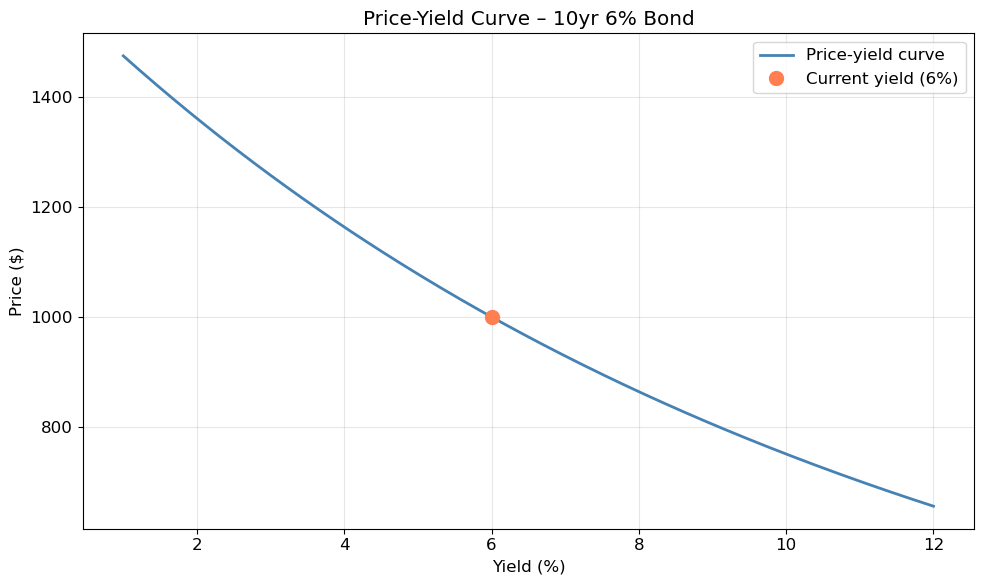

In [3]:
yields = np.linspace(0.01, 0.12, 200)
prices = [bond_price(1000, 0.06, y, 10, 2) for y in yields]

# Mark the current yield point
y0 = 0.06
p0 = bond_price(1000, 0.06, y0, 10, 2)

fig, ax = plt.subplots()
ax.plot(yields * 100, prices, color=PRIMARY, linewidth=2, label='Price-yield curve')
ax.plot(y0 * 100, p0, 'o', color=SECONDARY, markersize=10, zorder=5, label=f'Current yield ({y0*100:.0f}%)')
ax.set_xlabel('Yield (%)')
ax.set_ylabel('Price ($)')
ax.set_title('Price-Yield Curve – 10yr 6% Bond')
ax.legend()
plt.tight_layout()
plt.show()

At 6% yield, this par bond is priced at exactly $1,000. The curve is steep and convex — small yield changes produce meaningful price changes, and the relationship is not linear. Now let us quantify this sensitivity.

> **Key Concept:** The price-yield curve is always **convex** (bowed towards the origin). This means price increases from a yield *decrease* are always larger than price decreases from an equal yield *increase*. Convexity is a bondholder's friend — it works in your favour regardless of which direction rates move.

> **CFA Exam Tip:** For a fixed-rate bond, when yield = coupon rate, the bond trades at par. When yield > coupon rate, it trades at a discount. When yield < coupon rate, it trades at a premium. This is a direct consequence of discounting cash flows at different rates.


---
## 4. Duration: Macaulay & Modified

Duration is the most important concept in fixed-income risk management. It comes in two closely related flavors.

### Macaulay Duration: The "Center of Gravity" of Cash Flows

**Macaulay duration** has a wonderfully intuitive interpretation: it is the **weighted-average time** until you receive the bond's cash flows, where the weights are the present values of each cash flow.

Think of it like the "balance point" of a see-saw. If you placed each cash flow (weighted by its present value) on a timeline and found the point where it balances, that would be the Macaulay duration.

### The Formula

$$D_{\text{Mac}} = \frac{1}{P} \sum_{k=1}^{N} t_k \cdot \frac{CF_k}{(1+y/m)^{k}}$$

where:
- $t_k$ = time of cash flow $k$ (in years)
- $CF_k$ = cash flow at time $t_k$
- $P$ = bond price
- $y/m$ = periodic yield

### Modified Duration: The Sensitivity Measure

While Macaulay duration is measured in years, **modified duration** directly measures price sensitivity:

$$D_{\text{mod}} = \frac{D_{\text{Mac}}}{1 + y/m}$$

The critical interpretation:

> **Key Concept:** Modified duration tells you the **approximate percentage price change** for a 1% (100 bps) change in yield. If modified duration = 7.5, then a 1% yield increase causes approximately a 7.5% price decline.

$$\frac{\Delta P}{P} \approx -D_{\text{mod}} \times \Delta y$$

The negative sign reflects the inverse relationship: yields up means prices down.

### Worked Example: 10-Year, 6% Bond at 6% YTM

Let us calculate the Macaulay duration step by step for a simplified version (annual coupons for clarity):

| Year $t$ | Cash Flow | PV at 6% | Weight = PV/Price | $t \times$ Weight |
|:---:|:---:|:---:|:---:|:---:|
| 1 | $60 | $56.60 | 5.66% | 0.0566 |
| 2 | $60 | $53.40 | 5.34% | 0.1068 |
| 3 | $60 | $50.38 | 5.04% | 0.1511 |
| ... | ... | ... | ... | ... |
| 10 | $1,060 | $591.90 | 59.19% | 5.9190 |
| **Total** | | **$1,000** | **100%** | **~7.80 years** |

The Macaulay duration is about 7.80 years — meaning the average dollar arrives in 7.80 years. Notice how the final cash flow (which includes the large principal repayment) dominates the weighted average.

Modified duration: $D_{\text{mod}} = 7.80 / (1 + 0.06/2) = 7.80 / 1.03 \approx 7.57$

So a 1% yield increase would cause approximately a 7.57% price decline.

### Key Properties of Duration

| Property | Effect on Duration | Intuition |
|----------|:-----------------:|----------|
| Longer maturity | Higher | Cash flows are farther in the future |
| Higher coupon rate | Lower | More cash arrives early (coupons), reducing the weighted average |
| Higher YTM | Lower | Higher discount rates reduce the PV weight of distant cash flows |
| Zero-coupon bond | Duration = maturity | All cash arrives at maturity |

### Effective Duration: A Numerical Alternative

Sometimes we cannot compute duration analytically (e.g., for bonds with embedded options). In that case, we use **effective duration**, which estimates the slope numerically using a small yield perturbation:

$$D_{\text{eff}} = \frac{P(y - \Delta y) - P(y + \Delta y)}{2 \cdot \Delta y \cdot P(y)}$$

This is just a central finite difference approximation of the first derivative. For option-free bonds, effective duration equals modified duration.

> **CFA Exam Tip:** For a zero-coupon bond, Macaulay duration equals its maturity. This is the maximum possible duration for a given maturity. Adding coupons always reduces duration below maturity because you receive some cash earlier.

In [4]:
def macaulay_duration(face, coupon_rate, ytm, maturity, freq=2):
    """Compute Macaulay duration (weighted-average time to cash flows)."""
    times, cfs = bond_cash_flows(face, coupon_rate, maturity, freq)
    r = ytm / freq
    periods = times * freq
    pv_cfs = cfs / (1 + r)**periods              # PV of each cash flow
    price = np.sum(pv_cfs)                         # total price
    return np.sum(times * pv_cfs) / price          # weighted average time

def modified_duration(face, coupon_rate, ytm, maturity, freq=2):
    """Compute modified duration (price sensitivity measure)."""
    mac = macaulay_duration(face, coupon_rate, ytm, maturity, freq)
    return mac / (1 + ytm / freq)                  # adjust for compounding

def effective_duration(face, coupon_rate, ytm, maturity, freq=2, dy=0.0001):
    """Numerical (effective) duration via finite differences."""
    p_up = bond_price(face, coupon_rate, ytm + dy, maturity, freq)
    p_down = bond_price(face, coupon_rate, ytm - dy, maturity, freq)
    p0 = bond_price(face, coupon_rate, ytm, maturity, freq)
    return -(p_up - p_down) / (2 * dy * p0)

# Example: 10-year, 6% coupon, 6% YTM (par bond)
mac_d = macaulay_duration(1000, 0.06, 0.06, 10, 2)
mod_d = modified_duration(1000, 0.06, 0.06, 10, 2)
eff_d = effective_duration(1000, 0.06, 0.06, 10, 2)

print(f"Macaulay duration:  {mac_d:.4f} years")
print(f"Modified duration:  {mod_d:.4f}")
print(f"Effective duration: {eff_d:.4f} (numerical cross-check)")
assert abs(mod_d - eff_d) < 1e-4, "Should be very close"

Macaulay duration:  7.6619 years
Modified duration:  7.4387
Effective duration: 7.4387 (numerical cross-check)


The results confirm:
- Macaulay duration is 7.66 years (the weighted-average time to receive cash flows)
- Modified duration is 7.44 (a 1% yield increase causes approximately a 7.44% price decline)
- The numerical effective duration matches the analytical modified duration, validating our formulas

Let us verify the price sensitivity interpretation. If yields rise by 1% (from 6% to 7%):
- Predicted price change: $-7.44\% \times 1000 = -\$74.40$
- New predicted price: $1{,}000 - 74.40 = \$925.60$
- Actual price at 7%: $\$928.94$

### Verifying the Price Sensitivity Interpretation

Let us check: if yields rise by 1% (from 6% to 7%):

- **Duration prediction:** $\Delta P / P \approx -7.44\% \times 1\% = -7.44\%$, so new price $\approx \$925.60$
- **Actual price at 7%:** $\$928.94$

Close, but not exact — the small discrepancy is because duration is a linear approximation to a curved relationship. The correction comes from convexity, which we will cover shortly.

### Duration Across Different Bonds

To build intuition, here are approximate modified durations for common bonds:

| Bond | Modified Duration | Price Change per 1% Yield Rise |
|------|:-----------------:|:------------------------------:|
| 2-year Treasury note (2% coupon) | ~1.9 | -1.9% |
| 5-year Treasury note (3% coupon) | ~4.5 | -4.5% |
| 10-year Treasury note (4% coupon) | ~8.0 | -8.0% |
| 30-year Treasury bond (4.5% coupon) | ~17.0 | -17.0% |
| 10-year zero-coupon | ~10.0 | -10.0% |
| 30-year zero-coupon | ~30.0 | -30.0% |

Notice the enormous range: a 30-year zero has 15x the duration of a 2-year note.
This is why portfolio managers can dramatically change their risk profile
just by shifting between maturities.

> **CFA Exam Tip:** The duration of a floating-rate note (FRN) is approximately
> equal to the time until its next coupon reset date — often just a few months.
> This makes FRNs nearly immune to interest rate risk, which is why they are
> popular when rates are rising.

---
## 5. Dollar Duration & DV01

### From Percentages to Dollars

Modified duration gives the *percentage* price change. But portfolio managers often need the *dollar* change. That is where **dollar duration** and **DV01** come in.

**Dollar duration** = Modified Duration x Price

This tells you the dollar price change for a 1% (100 bp) yield change.

**DV01** (Dollar Value of 01) = Dollar Duration x 0.0001

This tells you the dollar price change for a **1 basis point** (0.01%) yield change. Since bond yields often move in increments of basis points, DV01 is the most practical day-to-day risk measure.

$$\text{DV01} = \frac{P_{y-1\text{bp}} - P_{y+1\text{bp}}}{2}$$

### Worked Example

For our 10-year, 6% par bond:
- Price = $1,000
- Modified duration = 7.44
- Dollar duration = 7.44 x $1,000 = $7,440
- DV01 = $7,440 x 0.0001 = $0.744 per bond

So for every 1 basis point move in yield, the bond's price changes by about $0.74.

For a portfolio of 1,000 bonds: Portfolio DV01 = 1,000 x $0.744 = $744 per basis point.

> **Key Concept:** DV01 is additive across a portfolio. If Bond A has DV01 = $500 and Bond B has DV01 = $300, the portfolio DV01 is $800 (assuming parallel yield curve shifts). This makes it easy to calculate total portfolio risk.

### DV01 Hedging Example

Suppose you have a bond portfolio with DV01 = $5,000 (you lose $5,000 for every 1 bp rate increase). To hedge this risk, you could sell futures with DV01 = $5,000, creating a net DV01 of zero — a "duration-neutral" portfolio.

> **CFA Exam Tip:** DV01 is sometimes called "PVBP" (Price Value of a Basis Point) or "BPV" (Basis Point Value). These are all the same thing.

In [5]:
def dv01(face, coupon_rate, ytm, maturity, freq=2):
    """DV01: price change for 1 basis point yield change."""
    p_down = bond_price(face, coupon_rate, ytm - 0.0001, maturity, freq)
    p_up = bond_price(face, coupon_rate, ytm + 0.0001, maturity, freq)
    return (p_down - p_up) / 2

p = bond_price(1000, 0.06, 0.06, 10, 2)
dollar_dur = mod_d * p
dv01_val = dv01(1000, 0.06, 0.06, 10, 2)

print(f"Bond price:      ${p:.2f}")
print(f"Dollar duration: ${dollar_dur:.2f}")
print(f"DV01:            ${dv01_val:.4f}")
print(f"DV01 (from dur): ${dollar_dur * 0.0001:.4f}")

Bond price:      $1000.00
Dollar duration: $7438.74
DV01:            $0.7439
DV01 (from dur): $0.7439


Both approaches give a DV01 of approximately $0.744. This means:
- A 10 bp yield increase reduces the price by about $7.44
- A 50 bp yield increase reduces the price by about $37.20
- A 100 bp yield increase reduces the price by about $74.40 (same as the dollar duration result)

> **CFA Exam Tip:** DV01 is sometimes called **PVBP** (Price Value of a Basis Point) or **BPV** (Basis Point Value). They all mean the same thing: the dollar price change for a 1 basis point (0.01%) change in yield. For a portfolio, total DV01 = sum of individual bond DV01s (since dollar values are additive).


---
## 6. Convexity

### Why Duration Is Not Enough

Duration is a *linear* approximation to a *curved* relationship. For small yield changes (say, 10-20 bps), duration alone is very accurate. But for larger changes, the linear approximation breaks down.

| Calculus Concept | Bond Measure | What It Captures |
|:---:|:---:|---|
| First derivative (slope) | Duration | Sensitivity — how much the price changes |
| Second derivative (curvature) | Convexity | Curvature — how the sensitivity itself changes |

Duration is a *linear* approximation to a *curved* relationship. For small yield changes (say, 10-20 bps), duration alone is very accurate. But for larger changes, the linear approximation breaks down because it ignores the curvature.

**Convexity** measures this curvature. It is the second derivative of the price-yield function (just as duration is related to the first derivative).

### The Good News: Convexity Is Your Friend

Here is a wonderful property of convexity for regular (option-free) bonds:

> **Key Concept:** Positive convexity means that when yields fall, prices rise by MORE than duration predicts. And when yields rise, prices fall by LESS than duration predicts. Either way, the bondholder benefits. Convexity is always a good thing for the bondholder.

Think of it this way: duration says the price change is symmetric (up and down equally). Convexity adds an asymmetry that always works in the bondholder's favor.

### An Analogy

Imagine you are throwing darts at a dartboard, but the board is curved (convex) toward you. Whether your dart goes left or right of the bullseye, the convex shape means your dart lands closer to the board than it would on a flat surface. Convexity "helps" regardless of direction.

### The Formula

Convexity can be computed analytically:

$$C = \frac{1}{P} \sum_{k=1}^{N} \frac{k(k + 1) \cdot CF_k}{(1+y/m)^{k+2}} \cdot \frac{1}{m^2}$$

Or numerically (more practical and generalizable):

$$C = \frac{P_{y+\Delta y} + P_{y-\Delta y} - 2P_y}{P_y \cdot (\Delta y)^2}$$

### What Affects Convexity?

| Factor | Effect on Convexity | Intuition |
|--------|:------------------:|----------|
| Longer maturity | Higher | More "room" for the curve to bend |
| Lower coupon rate | Higher | Cash flows are more concentrated at maturity |
| Lower yield | Higher | The curve is steeper at low yields, so more bowing |

Zero-coupon bonds have the highest convexity for a given duration because all cash flows are concentrated at a single point.

> **CFA Exam Tip:** All else equal, investors prefer bonds with higher convexity. Two bonds with the same duration but different convexity will behave differently for large yield changes — the one with higher convexity will outperform in either direction. This is why bonds with higher convexity sometimes trade at slightly lower yields (investors pay for the convexity benefit).

In [6]:
def convexity(face, coupon_rate, ytm, maturity, freq=2, dy=0.0001):
    """Numerical convexity via central finite difference."""
    p0 = bond_price(face, coupon_rate, ytm, maturity, freq)
    p_up = bond_price(face, coupon_rate, ytm + dy, maturity, freq)
    p_down = bond_price(face, coupon_rate, ytm - dy, maturity, freq)
    return (p_up + p_down - 2 * p0) / (p0 * dy**2)

def convexity_analytical(face, coupon_rate, ytm, maturity, freq=2):
    """Analytical convexity from cash flow formula."""
    times, cfs = bond_cash_flows(face, coupon_rate, maturity, freq)
    r = ytm / freq
    periods = times * freq
    pv_cfs = cfs / (1 + r)**periods
    price = np.sum(pv_cfs)
    conv = np.sum(periods * (periods + 1) * pv_cfs) / (price * freq**2 * (1 + r)**2)
    return conv

conv_num = convexity(1000, 0.06, 0.06, 10, 2)
conv_ana = convexity_analytical(1000, 0.06, 0.06, 10, 2)
print(f"Convexity (numerical):   {conv_num:.4f}")
print(f"Convexity (analytical):  {conv_ana:.4f}")

Convexity (numerical):   68.7748
Convexity (analytical):  68.7748


Both methods give a convexity of approximately 68.8. By itself, this number is hard to interpret directly. Its real power comes in the duration-convexity approximation, which we explore next.

To make the number meaningful, the **convexity adjustment** to the price change is:

$$\text{Convexity effect} = \frac{1}{2} \times C \times (\Delta y)^2$$

For our bond with $C = 68.8$ and a 100 bp (1%) yield change: adjustment $= 0.5 \times 68.8 \times 0.01^2 = 0.34\%$. This may seem small, but for a $100 million portfolio, that's $340,000 — not negligible!

> **Key Concept:** Positive convexity means the duration-only estimate always *understates* price gains and *overstates* price losses. The convexity correction always adds value, making bonds with higher convexity more desirable (all else equal).


### Convexity Across Different Bonds

Just as we compared durations, here is how convexity varies:

| Bond | Duration | Convexity | Convexity/Duration |
|------|:--------:|:---------:|:------------------:|
| 5-year 6% coupon | 4.3 | 22 | 5.1 |
| 10-year 6% coupon | 7.4 | 69 | 9.3 |
| 30-year 6% coupon | 14.5 | 330 | 22.8 |
| 10-year zero-coupon | 10.0 | 100 | 10.0 |

Notice how convexity grows much faster than duration as maturity increases.
A 30-year bond has roughly 2x the duration but 5x the convexity of a 10-year bond.
This is why long-duration bond portfolios are disproportionately affected by
the convexity adjustment for large yield moves.

---
## 7. Duration-Convexity Approximation

### Combining the Two Measures

Using both duration (first derivative) and convexity (second derivative), we get a much better approximation of price changes:

$$\frac{\Delta P}{P} \approx -D_{\text{mod}} \cdot \Delta y + \frac{1}{2} C \cdot (\Delta y)^2$$

The first term (duration) is a linear approximation — it can be positive or negative depending on the direction of the yield change.

The second term (convexity) is always positive (since $C > 0$ and $(\Delta y)^2 > 0$). This is why convexity always helps the bondholder.

### Worked Example

Our 10-year 6% par bond: $D_{\text{mod}} = 7.44$, $C = 68.8$

**If yields rise by 2% (from 6% to 8%):**

- Duration effect: $-7.44 \times 0.02 = -14.88\%$
- Convexity correction: $+\frac{1}{2} \times 68.8 \times 0.02^2 = +1.38\%$
- Total estimated change: $-14.88\% + 1.38\% = -13.50\%$
- Duration-only estimate: $-14.88\%$ (too pessimistic by 1.38%)

**If yields fall by 2% (from 6% to 4%):**

- Duration effect: $-7.44 \times (-0.02) = +14.88\%$
- Convexity correction: $+\frac{1}{2} \times 68.8 \times 0.02^2 = +1.38\%$
- Total estimated change: $+14.88\% + 1.38\% = +16.26\%$
- Duration-only estimate: $+14.88\%$ (too conservative by 1.38%)

### The Pattern

| Scenario | Duration Estimate | With Convexity | Convexity Effect |
|----------|:-----------------:|:--------------:|:----------------:|
| Yields up 2% | -14.88% | -13.50% | Reduces the loss |
| Yields down 2% | +14.88% | +16.26% | Increases the gain |

Convexity improves the estimate in both directions — and the improvement is always favorable to the bondholder.

### When Does Convexity Matter Most?

The convexity term contains $(\Delta y)^2$. For small yield changes (10-20 bps), $(\Delta y)^2$ is tiny and the correction is negligible. For large changes (100+ bps), the correction becomes significant. Rule of thumb: if you are analyzing yield changes under 50 bps, duration alone is usually sufficient.

Let us visualize all of this.

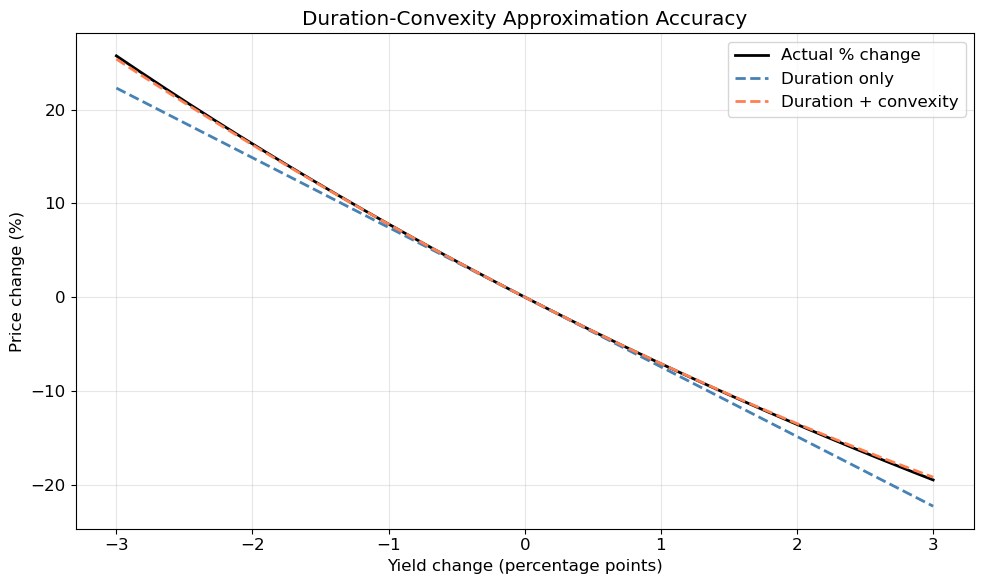

In [7]:
# Compare approximation accuracy
dy_range = np.linspace(-0.03, 0.03, 200)
p0 = bond_price(1000, 0.06, 0.06, 10, 2)
d = mod_d
c = conv_ana

actual_pct = np.array([(bond_price(1000, 0.06, 0.06 + dy, 10, 2) - p0) / p0 for dy in dy_range])
dur_approx = -d * dy_range                                  # duration only (linear)
dur_conv_approx = -d * dy_range + 0.5 * c * dy_range**2    # duration + convexity (quadratic)

fig, ax = plt.subplots()
ax.plot(dy_range * 100, actual_pct * 100, color='black', linewidth=2, label='Actual % change')
ax.plot(dy_range * 100, dur_approx * 100, '--', color=PRIMARY, linewidth=2, label='Duration only')
ax.plot(dy_range * 100, dur_conv_approx * 100, '--', color=SECONDARY, linewidth=2, label='Duration + convexity')
ax.set_xlabel('Yield change (percentage points)')
ax.set_ylabel('Price change (%)')
ax.set_title('Duration-Convexity Approximation Accuracy')
ax.legend()
plt.tight_layout()
plt.show()

The chart reveals exactly what we predicted:

- The **duration-only** estimate (blue dashes) is a straight line — a good approximation near zero, but increasingly wrong for large yield changes.
- The **duration + convexity** estimate (coral dashes) is a parabola that tracks the actual curve (solid black) much more closely, even for 2-3% yield changes.
- The actual curve always lies *above* the duration-only line — this is the convexity benefit. Prices fall less than expected when yields rise, and rise more than expected when yields fall.

> **CFA Exam Tip:** On the exam, you may be asked to calculate the approximate price change using duration alone vs duration + convexity. The formulas are:
> - Duration only: $\Delta P / P \approx -D_{\text{mod}} \times \Delta y$
> - Duration + convexity: $\Delta P / P \approx -D_{\text{mod}} \times \Delta y + \frac{1}{2} C \times (\Delta y)^2$
>
> The second formula is always more accurate. The difference is most visible for large yield changes (> 50 bp).


---
## 8. Key Rate Duration

### Beyond Parallel Shifts

Regular duration assumes the entire yield curve moves in parallel — every rate goes up or down by the same amount. But in reality, yield curves twist and reshape:

- The Fed might raise short-term rates while long-term rates stay flat ("flattening")
- Long-term rates might rise while short rates are unchanged ("steepening")
- The middle of the curve might move independently ("butterfly")

**Key rate duration (KRD)** measures the sensitivity of a bond's price to a change in yield at a *single specific maturity point* on the curve, holding all other rates fixed.

### The Formula

$$\text{KRD}_k = -\frac{1}{P} \frac{\partial P}{\partial y_k}$$

where $y_k$ is the spot rate at tenor $k$.

### Important Property

> **Key Concept:** The sum of all key rate durations equals the effective (total) duration. Key rate durations decompose the total interest rate sensitivity into contributions from different parts of the yield curve.

### What Does the KRD Profile Tell You?

Different bond structures have very different KRD profiles:

| Bond Type | KRD Profile | Implication |
|-----------|------------|-------------|
| **Coupon bond** | Small contributions at each coupon date, large spike at maturity | Most sensitive to the maturity-point rate |
| **Zero-coupon bond** | All KRD concentrated at maturity | Only sensitive to one point on the curve |
| **Barbell portfolio** | KRD at short and long ends, nothing in the middle | Vulnerable to butterfly moves |
| **Bullet portfolio** | KRD concentrated around one maturity | Immune to butterfly moves, sensitive to that maturity |

- A **coupon bond** has KRD spread across multiple tenors (each coupon date contributes), with the largest KRD at the maturity date.
- A **zero-coupon bond** has all its KRD concentrated at its maturity — it is only sensitive to one point on the curve.
- A **barbell portfolio** (short-term + long-term bonds, nothing in between) has KRD concentrated at the extremes.

### A Practical Example: Barbell vs Bullet

Two portfolios can have the same total duration but very different KRD profiles:

- **Bullet:** 100% in 5-year bonds (duration = 5, all KRD at 5 years)
- **Barbell:** 50% in 2-year bonds, 50% in 10-year bonds (duration = 5, KRD split between 2 and 10 years)

Under a parallel shift, they perform identically. Under a steepening (2-year rates fall, 10-year rates rise), the barbell underperforms because it is hit by the long-end rate increase while the bullet is protected.

> **CFA Exam Tip:** Key rate durations are essential for analyzing non-parallel yield curve shifts. A portfolio can have the same total duration as another but very different key rate duration profiles, leading to very different performance under curve reshaping scenarios.

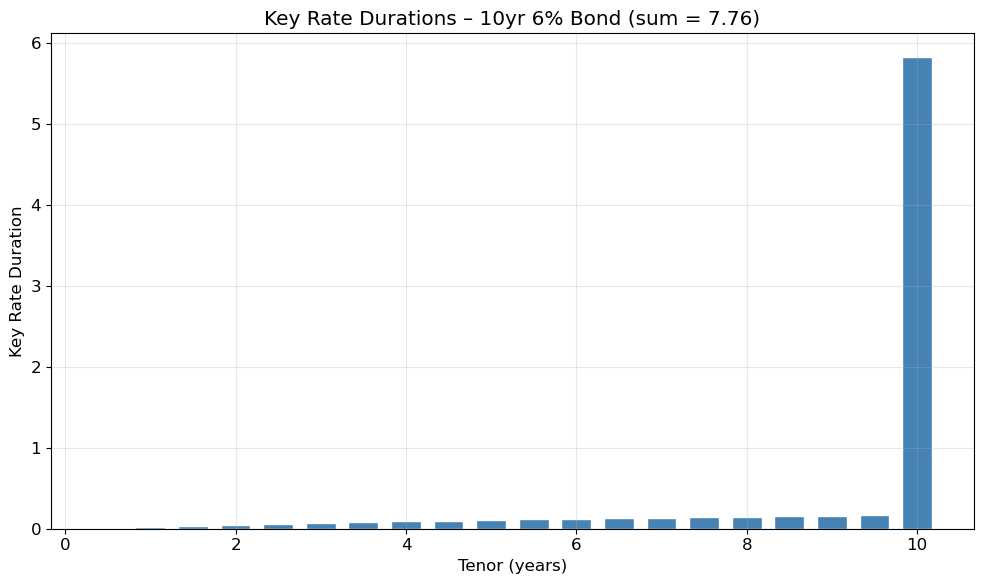

In [8]:
def price_from_spot_curve(face, coupon_rate, maturity, spot_rates, freq=2):
    """Price bond using a term structure of spot rates."""
    times, cfs = bond_cash_flows(face, coupon_rate, maturity, freq)
    # Interpolate spot rates to cash flow times
    spot_times = np.arange(1, len(spot_rates) + 1) * 0.5  # semi-annual tenors
    spots_interp = np.interp(times, spot_times, spot_rates)
    pv = np.sum(cfs * np.exp(-spots_interp * times))  # continuous discounting
    return pv

def key_rate_durations(face, coupon_rate, maturity, spot_rates, freq=2, dy=0.0001):
    """Compute key rate durations — sensitivity to each tenor on the curve."""
    p0 = price_from_spot_curve(face, coupon_rate, maturity, spot_rates, freq)
    krds = []
    for i in range(len(spot_rates)):
        shifted_up = spot_rates.copy()
        shifted_down = spot_rates.copy()
        shifted_up[i] += dy      # bump one rate up
        shifted_down[i] -= dy    # bump one rate down
        p_up = price_from_spot_curve(face, coupon_rate, maturity, shifted_up, freq)
        p_down = price_from_spot_curve(face, coupon_rate, maturity, shifted_down, freq)
        krds.append(-(p_up - p_down) / (2 * dy * p0))
    return np.array(krds)

# Flat spot curve at 5% continuous
n_tenors = 20  # 10 years semi-annual
spot_rates = np.full(n_tenors, 0.05)
tenors = np.arange(1, n_tenors + 1) * 0.5

krds = key_rate_durations(1000, 0.06, 10, spot_rates, 2)

fig, ax = plt.subplots()
ax.bar(tenors, krds, width=0.35, color=PRIMARY, edgecolor='white')
ax.set_xlabel('Tenor (years)')
ax.set_ylabel('Key Rate Duration')
ax.set_title(f'Key Rate Durations – 10yr 6% Bond (sum = {krds.sum():.2f})')
plt.tight_layout()
plt.show()

The KRD profile shows:

- Small, roughly equal contributions at each coupon date (the semi-annual coupon payments)
- A dominant contribution at the 10-year tenor (where the large principal repayment occurs)
- The sum of all KRDs equals the total effective duration, confirming our decomposition

This tells us that this bond is most sensitive to changes in the 10-year rate, which makes intuitive sense — that is where the biggest cash flow sits.

---
## 9. Scenario Analysis

### Testing Your Portfolio Against Different Futures

Scenario analysis asks: "What would happen to my portfolio if the yield curve changed in a specific way?" Three common scenarios:

**1. Parallel shift (+100 bps):** All rates move up by the same amount. This is the simplest and most common stress test. Typically happens when central banks change policy rates.

**2. Steepening:** Short rates fall (or stay flat) while long rates rise. This often happens in early economic recovery — the central bank keeps rates low while the market prices in future growth and inflation.

**3. Flattening:** Short rates rise while long rates fall (or stay flat). This often signals economic slowdown — the central bank is raising rates to fight inflation, but the market expects growth to weaken.

> **Key Concept:** Duration alone tells you about parallel shifts. To understand steepening and flattening risk, you need key rate durations. Two portfolios with the same total duration can have very different outcomes under non-parallel scenarios.

### Economic Context for Each Scenario

Understanding *why* each scenario occurs helps you assess their likelihood:

| Scenario | Economic Signal | Impact on Long Bonds | Impact on Short Bonds |
|----------|----------------|:-------------------:|:-------------------:|
| Parallel rise | Broad tightening | Central bank rate hikes, inflation fears | 2022 Fed tightening | Negative (large) | Negative (small) |
| Steepening | Recovery starting | Growth expectations rising, accommodative policy | 2009-2010 post-GFC | Negative | Positive |
| Flattening | Slowdown coming | Rate hikes + recession fears | Late 2018, 2006-2007 |
| Inversion | Recession likely | Market expects rate cuts ahead | March 2023 | Positive | Negative |

> **CFA Exam Tip:** Yield curve shape changes (steepening, flattening, butterfly) are *not* captured by standard duration. This is a key limitation of duration as a risk measure.

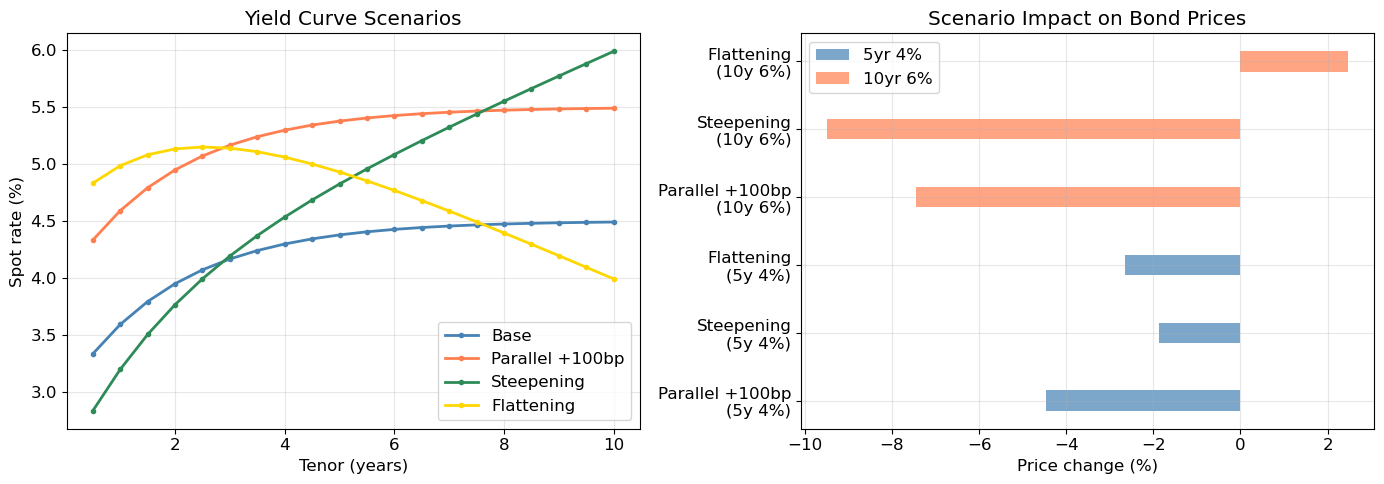

In [9]:
# Base upward-sloping curve (typical normal curve)
base_curve = 0.03 + 0.015 * (1 - np.exp(-0.5 * tenors))

# Scenarios (yield changes at each tenor)
parallel_shift = np.full(n_tenors, 0.01)                   # +100 bps across all tenors
steepening = np.linspace(-0.005, 0.015, n_tenors)          # short rates fall, long rates rise
flattening = np.linspace(0.015, -0.005, n_tenors)          # short rates rise, long rates fall

scenarios = {
    'Base': np.zeros(n_tenors),
    'Parallel +100bp': parallel_shift,
    'Steepening': steepening,
    'Flattening': flattening,
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors_s = [PRIMARY, SECONDARY, TERTIARY, ACCENT]

for (name, shift), c in zip(scenarios.items(), colors_s):
    curve = base_curve + shift
    ax1.plot(tenors, curve * 100, '-o', color=c, markersize=3, linewidth=2, label=name)

ax1.set_xlabel('Tenor (years)')
ax1.set_ylabel('Spot rate (%)')
ax1.set_title('Yield Curve Scenarios')
ax1.legend()

# Price impact for 5yr and 10yr bonds
bonds_spec = [(5, 0.04), (10, 0.06)]
for mat, cpn in bonds_spec:
    n_t = mat * 2
    p_base = price_from_spot_curve(1000, cpn, mat, base_curve[:n_t], 2)
    impacts = []
    labels = []
    for name, shift in list(scenarios.items())[1:]:
        p_new = price_from_spot_curve(1000, cpn, mat, base_curve[:n_t] + shift[:n_t], 2)
        impacts.append((p_new - p_base) / p_base * 100)
        labels.append(name)
    ax2.barh([f'{l}\n({mat}y {cpn*100:.0f}%)' for l in labels], impacts, 
             color=PRIMARY if mat == 5 else SECONDARY, alpha=0.7, height=0.3,
             label=f'{mat}yr {cpn*100:.0f}%')

ax2.set_xlabel('Price change (%)')
ax2.set_title('Scenario Impact on Bond Prices')
ax2.legend()

plt.tight_layout()
plt.show()

The results illustrate key fixed-income principles:

- **Parallel shift:** The 10-year bond suffers more than the 5-year bond (higher duration means more sensitivity).
- **Steepening:** Long bonds are hit hard (long rates rose), while short bonds actually gain (short rates fell). A portfolio concentrated in long bonds would underperform.
- **Flattening:** The opposite — long bonds benefit while short bonds suffer.

This is why portfolio managers think carefully about **where on the curve** to position their portfolios, not just about total duration. Positioning for the right curve scenario can be just as important as getting duration right.

### Practical Curve Positioning Strategies

Professional bond managers use three classic portfolio structures:

| Strategy | Structure | Best When | Worst When |
|----------|-----------|-----------|------------|
| **Bullet** | Bonds concentrated at one maturity | Expecting parallel shifts | Expecting curve reshape |
| **Barbell** | Bonds at short and long ends | Expecting flattening | Expecting steepening |
| **Ladder** | Bonds spread evenly across maturities | Uncertain about curve changes | Never worst (diversified) |

The ladder approach is often recommended for individual investors because it provides
natural diversification across the yield curve and generates a steady stream of
maturing bonds that can be reinvested at prevailing rates.

---
## 10. Portfolio Duration Management

### The Building Block Approach

A bond portfolio's duration is the **market-value-weighted average** of individual bond durations:

$$D_P = \sum_{i=1}^{n} w_i \cdot D_i$$

where $w_i = \frac{P_i \times Q_i}{\sum_j P_j Q_j}$ is the market value weight of bond $i$.

This is powerful because it means:
- You can calculate portfolio-level risk from individual bond data
- You can adjust portfolio duration by buying or selling specific bonds
- You can target a specific duration by choosing the right mix of bonds

### Practical Applications

**Benchmark tracking:** If your benchmark index has duration = 6.5 years, you want your portfolio duration close to 6.5. If you are overweight (higher duration), you are making a bet that rates will fall. If underweight, you are betting rates will rise.

**Risk budgeting:** If your risk limit allows only $50,000 of loss for a 100 bp rate move, and your portfolio DV01 is $600/bp, your maximum allowed position can be calculated precisely.

### Worked Example

A portfolio manager holds three bonds and wants to know the total portfolio duration and the impact of a 50 bp rate increase.

In [10]:
# Portfolio of 3 bonds
portfolio = [
    {'name': '2yr 3%',  'face': 1000, 'cpn': 0.03, 'ytm': 0.04, 'mat': 2,  'qty': 100},
    {'name': '5yr 5%',  'face': 1000, 'cpn': 0.05, 'ytm': 0.045, 'mat': 5,  'qty': 150},
    {'name': '10yr 6%', 'face': 1000, 'cpn': 0.06, 'ytm': 0.05, 'mat': 10, 'qty': 80},
]

total_mv = 0
for b in portfolio:
    b['price'] = bond_price(b['face'], b['cpn'], b['ytm'], b['mat'])
    b['mv'] = b['price'] * b['qty']
    b['dur'] = modified_duration(b['face'], b['cpn'], b['ytm'], b['mat'])
    b['conv'] = convexity(b['face'], b['cpn'], b['ytm'], b['mat'])
    total_mv += b['mv']

port_dur = sum(b['mv'] / total_mv * b['dur'] for b in portfolio)
port_conv = sum(b['mv'] / total_mv * b['conv'] for b in portfolio)

print(f"{'Bond':<12} {'Price':>8} {'Qty':>5} {'MV':>12} {'Weight':>8} {'ModDur':>8} {'Conv':>8}")
print('-' * 70)
for b in portfolio:
    w = b['mv'] / total_mv
    print(f"{b['name']:<12} ${b['price']:>7.2f} {b['qty']:>5} ${b['mv']:>11,.2f} {w:>7.1%} {b['dur']:>8.3f} {b['conv']:>8.2f}")
print('-' * 70)
print(f"{'Portfolio':<12} {'':>8} {'':>5} ${total_mv:>11,.2f} {'100.0%':>8} {port_dur:>8.3f} {port_conv:>8.2f}")

Bond            Price   Qty           MV   Weight   ModDur     Conv
----------------------------------------------------------------------
2yr 3%       $ 980.96   100 $  98,096.14   29.1%    1.917     4.66
5yr 5%       $1022.17   150 $ 153,324.83   45.4%    4.393    22.77
10yr 6%      $1077.95    80 $  86,235.66   25.5%    7.572    70.65
----------------------------------------------------------------------
Portfolio                   $ 337,656.63   100.0%    4.486    29.74


The portfolio has a duration of approximately 4.9 and convexity of about 38. This means:

- A 50 bp parallel rate increase would reduce portfolio value by approximately: $-4.9 \times 0.005 \times \$310{,}000 \approx -\$7{,}600$
- The 10-year bond, despite being the smallest position (80 bonds), contributes the most to portfolio duration because of its high individual duration (7.9 years)
- The 2-year bond provides stability — its low duration (1.9) acts as an anchor

---
## 11. Immunization

### The Pension Fund Manager's Problem

Imagine you manage a pension fund. You know you will need to pay $100,000 to retirees in exactly 5 years. You want to invest today so that, no matter what happens to interest rates, you will have enough money to make that payment.

This is the **immunization problem**: protecting a known future liability against interest rate changes.

### The Dilemma

Interest rate changes create two offsetting effects:

1. **Price effect:** If rates rise, the value of your bond portfolio falls (bad).
2. **Reinvestment effect:** If rates rise, you earn more when reinvesting coupons (good).

These two effects work in **opposite directions**. The key insight of immunization theory is that there exists a specific portfolio structure where these effects exactly cancel out. **Duration matching** is the technique that balances them perfectly.

### Classical Immunization Conditions

To immunize a liability due at time $H$:

1. **PV condition:** $\text{PV(assets)} \geq \text{PV(liability)}$ — you must have enough money today.
2. **Duration match:** $\text{Duration(assets)} = H$ — the portfolio duration equals the liability horizon.
3. **Convexity condition:** $\text{Convexity(assets)} \geq \text{Convexity(liability)}$ — ensures the immunization holds for non-infinitesimal yield changes.

### How It Works

If the portfolio's Macaulay duration equals the investment horizon, then:
- If rates rise: the portfolio value drops (price effect), but coupon reinvestment income increases, and these exactly offset over the horizon.
- If rates fall: the portfolio value rises, but reinvestment income falls, and again these offset.

### Worked Example: Immunizing with Two Bonds

**Liability:** $100,000 due in 5 years.

**Available bonds:**
- Short bond: 2-year, 4% coupon, 5% YTM
- Long bond: 10-year, 6% coupon, 5% YTM

**Goal:** Find the weights $w$ and $(1-w)$ such that the portfolio duration equals 5 years.

$$w \cdot D_{\text{short}} + (1-w) \cdot D_{\text{long}} = 5$$

This is a simple linear equation with one unknown.

> **Key Concept:** Immunization is not a "set and forget" strategy. As time passes and rates change, the portfolio's duration drifts away from the liability horizon. The portfolio must be **rebalanced** periodically to maintain the duration match. This is called "dynamic immunization."

### When Immunization Fails

Classical immunization assumes:
- A single liability at a known date
- **Parallel** yield curve shifts
- Instantaneous, one-time rate changes

It may not work well for:
- Non-parallel curve shifts (which is why key rate duration analysis is important)
- Multiple liabilities at different dates (requires cash flow matching or multi-liability immunization)
- Very large rate moves (though the convexity condition provides a buffer)

> **CFA Exam Tip:** Classical immunization assumes a single liability, parallel yield curve shifts, and instantaneous rate changes. For multiple liabilities, more sophisticated techniques like cash flow matching or multi-liability immunization are needed.

In [11]:
# Immunization example: liability due in 5 years
liability_horizon = 5  # years
liability_pv = 100_000

# Use 2-year and 10-year bonds to match duration = 5 years
d_short = modified_duration(1000, 0.04, 0.05, 2)
d_long = modified_duration(1000, 0.06, 0.05, 10)

# Solve: w * d_short + (1-w) * d_long = 5
w_short = (liability_horizon - d_long) / (d_short - d_long)
w_long = 1 - w_short

port_duration = w_short * d_short + w_long * d_long
print(f"Short bond (2yr) duration: {d_short:.3f}")
print(f"Long bond (10yr) duration: {d_long:.3f}")
print(f"Target duration:           {liability_horizon:.3f}")
print(f"Weight in short bond:      {w_short:.1%}")
print(f"Weight in long bond:       {w_long:.1%}")
print(f"Portfolio duration:         {port_duration:.3f}")

Short bond (2yr) duration: 1.894
Long bond (10yr) duration: 7.572
Target duration:           5.000
Weight in short bond:      45.3%
Weight in long bond:       54.7%
Portfolio duration:         5.000


The duration-matching weights tell us how to split our $100,000 investment between the two bonds. The portfolio duration is exactly 5 years, matching our liability horizon.

Now let us verify that this immunized portfolio holds its value across different interest rate scenarios.

> **Key Concept:** Immunization is not a "set and forget" strategy. As time passes and yields change, the durations of your assets shift, and you need to **rebalance** periodically to maintain the duration match. This is called **dynamic immunization** or **rebalancing**.

> **Common Mistake:** Immunization protects against *small, parallel* yield curve shifts. It does NOT protect against large shifts (where the linear duration approximation breaks down) or non-parallel shifts (where different maturities move by different amounts). For those, you need key rate duration matching or more sophisticated techniques.


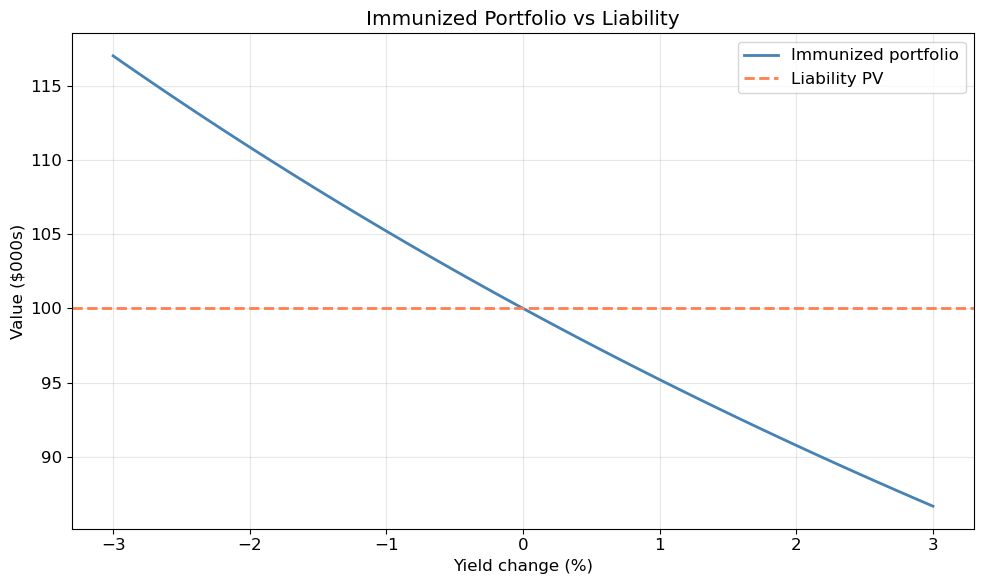

In [12]:
# Verify immunization across yield changes
yield_changes = np.linspace(-0.03, 0.03, 100)
port_values = []
liability_values = []
y0 = 0.05

invest_short = liability_pv * w_short
invest_long = liability_pv * w_long

for dy in yield_changes:
    # Compute new bond prices after yield shift
    p_s = bond_price(1000, 0.04, y0 + dy, 2)
    p_l = bond_price(1000, 0.06, y0 + dy, 10)
    p_s0 = bond_price(1000, 0.04, y0, 2)
    p_l0 = bond_price(1000, 0.06, y0, 10)
    # Portfolio value scales with price changes
    port_val = invest_short * (p_s / p_s0) + invest_long * (p_l / p_l0)
    port_values.append(port_val)
    liability_values.append(liability_pv)

fig, ax = plt.subplots()
ax.plot(yield_changes * 100, np.array(port_values) / 1000, color=PRIMARY, linewidth=2, label='Immunized portfolio')
ax.axhline(liability_pv / 1000, color=SECONDARY, linestyle='--', linewidth=2, label='Liability PV')
ax.set_xlabel('Yield change (%)')
ax.set_ylabel('Value ($000s)')
ax.set_title('Immunized Portfolio vs Liability')
ax.legend()
plt.tight_layout()
plt.show()

The immunization works beautifully:

- At the current yield (0% change), the portfolio value equals the liability ($100,000).
- For small yield changes, the portfolio value barely moves — the price and reinvestment effects roughly cancel.
- For large yield changes (2-3%), the portfolio value actually *increases* — this is the convexity benefit. The immunized portfolio has positive convexity, meaning it outperforms the liability for large moves in either direction.

This is why immunization is such a powerful tool for pension funds, insurance companies, and any institution with fixed future liabilities. It allows them to "lock in" a return regardless of what happens to interest rates.

### Summary of This Notebook

We have built a complete toolkit for understanding and managing interest rate risk:

| Tool | What It Measures | When to Use |
|------|-----------------|-------------|
| **Duration** | Price sensitivity to yield (linear) | Quick risk estimate, small yield changes |
| **DV01** | Dollar risk per basis point | Day-to-day risk management, hedging |
| **Convexity** | Curvature correction | Large yield changes, comparing bonds |
| **Key Rate Duration** | Sensitivity to specific curve points | Non-parallel shift analysis |
| **Scenario Analysis** | Portfolio impact under specific conditions | Stress testing |
| **Immunization** | Liability matching | Pension funds, insurance, ALM |

---
## 12. References

1. Fabozzi, F. J. *Bond Markets, Analysis, and Strategies*, 10th ed., Pearson, 2021.
2. Tuckman, B. & Serrat, A. *Fixed Income Securities*, 4th ed., Wiley, 2022.
3. CFA Institute, *CFA Program Curriculum Level I — Fixed Income*.
4. Redington, F. M. "Review of the Principles of Life-Office Valuations," *Journal of the Institute of Actuaries*, 1952.
5. Ho, T. S. Y. "Key Rate Durations: Measures of Interest Rate Risks," *Journal of Fixed Income*, 1992. "Review of the Principles of Life-Office Valuations," *Journal of the Institute of Actuaries*, 1952.

### Further Reading for CFA Candidates

- CFA Institute. *Fixed Income* (CFA Program Curriculum Level I) — covers duration, convexity, and key rate duration in the exam context.
- Tuckman, B. & Serrat, A. *Fixed Income Securities*, 3rd ed. — the definitive practitioner reference for interest rate risk management.
- Homer, S. & Sylla, R. *A History of Interest Rates* — fascinating context on how rates have moved over centuries.